In [1]:
import pandas as pd
df = pd.read_csv('../data/train.csv')

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [3]:
#remove label columns apart from toxic
df = df.drop( columns = ['severe_toxic','obscene','threat','insult','identity_hate'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            159571 non-null  object
 1   comment_text  159571 non-null  object
 2   toxic         159571 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 3.7+ MB


In [4]:
#basic text cleaning

import re
import contractions


def clean_text(text):

    if not isinstance(text, str):
        return ""                              #handle NaN safely

    text = text.lower()                        #lowercase
    text = contractions.fix(text)              #contraction expansion
    text = re.sub(r'http\S+|www\S+', ' URL ', text)  #keep URL signal before removing symbols
    text = re.sub(r'[^a-z]', ' ', text)        #replace non-alphabet with space
    text = re.sub(r'\s+', ' ', text).strip()   #remove extra space

    return text


# apply clean text to new column

df['raw_text'] = df['comment_text'].fillna('').astype(str)
df['clean_text'] = df['raw_text'].apply(clean_text)

#remove empty rowes after cleaning
df = df[df['clean_text'] != ""].copy()


In [5]:
#drop duplications

df = df.drop_duplicates( subset = ['clean_text'] )

In [6]:
#info about data after cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 158194 entries, 0 to 159570
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            158194 non-null  object
 1   comment_text  158194 non-null  object
 2   toxic         158194 non-null  int64 
 3   raw_text      158194 non-null  object
 4   clean_text    158194 non-null  object
dtypes: int64(1), object(4)
memory usage: 7.2+ MB


In [7]:
#label distribution
df['toxic'].value_counts()

toxic
0    143038
1     15156
Name: count, dtype: int64

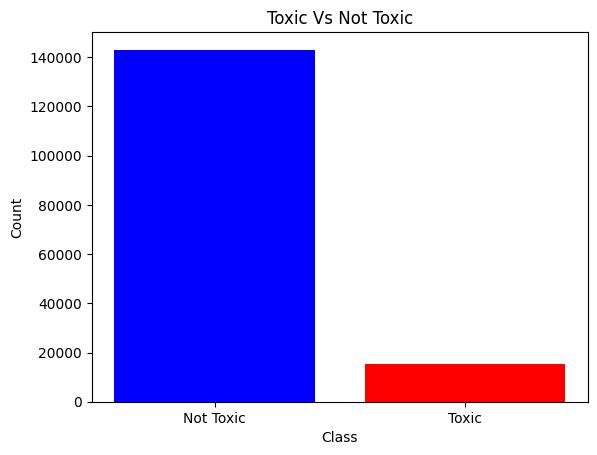

In [8]:
#bar graph for label distribution

import matplotlib.pyplot as plt

plt.bar(['Not Toxic','Toxic'] , df['toxic'].value_counts(), color = ['blue', 'red'])
plt.title('Toxic Vs Not Toxic')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [9]:
#generate clean data set file
# df.to_csv('clean_data.csv', index = False )

In [10]:
df

,id,comment_text,toxic,raw_text,clean_text
0,0000997932d777bf,Explanation\r\nWhy the edits made under my use...,0,Explanation\r\nWhy the edits made under my use...,explanation why the edits made under my userna...
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,D'aww! He matches this background colour I'm s...,d aww he matches this background colour i am s...
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,"Hey man, I'm really not trying to edit war. It...",hey man i am really not trying to edit war it ...
3,0001b41b1c6bb37e,"""\r\nMore\r\nI can't make any real suggestions...",0,"""\r\nMore\r\nI can't make any real suggestions...",more i cannot make any real suggestions on imp...
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,"You, sir, are my hero. Any chance you remember...",you sir are my hero any chance you remember wh...
...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,""":::::And for the second time of asking, when ...",and for the second time of asking when your vi...
159567,ffea4adeee384e90,You should be ashamed of yourself \r\n\r\nThat...,0,You should be ashamed of yourself \r\n\r\nThat...,you should be ashamed of yourself that is a ho...
159568,ffee36eab5c267c9,"Spitzer \r\n\r\nUmm, theres no actual article ...",0,"Spitzer \r\n\r\nUmm, theres no actual article ...",spitzer umm there is no actual article for pro...
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,And it looks like it was actually you who put ...,and it looks like it was actually you who put ...


In [11]:
oangsa_features = [
    "Word TF-IDF",
    "Character Count",
    "Word Count",
    "Exclamation Count",
    "Profanity Count",
    "Strong Toxic Signal Flag",
    "Second-person Pronoun Count",
    "Repeated Character Pattern Count",
    "Average Word Length"
]

ploy_features = [
    "Character TF-IDF",
    "Uppercase Ratio",
    "Question Mark Count",
    "Repeated Punctuation Count",
    "Identity-group Term Count",
    "URL Count",
    "Negation Count",
    "Non-toxic Negation Pattern Count",
    "Short/Unclear Without Toxic Signal Flag"
]


In [12]:
# implement Word TF-IDF and Character TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

word_tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)
word_tfidf_features = word_tfidf_vectorizer.fit_transform(df["clean_text"])

char_tfidf_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=10000,
    min_df=2,
    sublinear_tf=True
)
char_tfidf_features = char_tfidf_vectorizer.fit_transform(df["raw_text"])


print(f"Word TF-IDF shape: {word_tfidf_features.shape}")
print(f"Character TF-IDF shape: {char_tfidf_features.shape}")


Word TF-IDF shape: (158194, 10000)
Character TF-IDF shape: (158194, 10000)


In [13]:
# feature helper functions and dictionaries

PROFANITY_TERMS = [
    'fuck', 'fucking', 'shit', 'bitch', 'bastard', 'asshole', 'idiot', 'moron',
    'dumb', 'stupid', 'suck', 'crap', 'damn', 'jerk', 'loser', 'trash'
]

IDENTITY_TERMS = [
    'black', 'white', 'gay', 'lesbian', 'transgender', 'trans', 'muslim',
    'jewish', 'christian', 'hispanic', 'asian', 'woman', 'women', 'man', 'men'
]

SECOND_PERSON_TERMS = ['you', 'your', 'yours', 'yourself', 'u']
NEGATION_TERMS = ['not', 'never', 'no', 'none', 'cannot', 'cant', 'do not']
NON_TOXIC_NEGATION_PATTERNS = [
    r'\bnot\s+(?:stupid|dumb|idiot|moron|trash|wrong|bad|terrible|awful|useless)\b',
    r'\bnot\s+(?:an|a)\s+(?:idiot|moron|loser|bastard|fool)\b',
    r'\bdo\s+not\s+(?:like|love|agree|hate|dislike|attack|insult|blame)\b',
    r'\bcannot\s+(?:hate|blame)\b',
    r'\bnot\s+trying\s+to\s+(?:attack|insult|offend)\b',
]

COMMON_SHORT_TOKENS = {
    'i', 'me', 'my', 'you', 'your', 'yours', 'yourself', 'it', 'this', 'that',
    'a', 'an', 'the', 'is', 'am', 'are', 'was', 'were', 'be', 'to', 'of', 'and'
}


def make_term_pattern(terms):
    escaped_terms = sorted((re.escape(term) for term in terms), key=len, reverse=True)
    return re.compile(r'\b(?:' + '|'.join(escaped_terms) + r')\b')


PROFANITY_PATTERN = make_term_pattern(PROFANITY_TERMS)
IDENTITY_PATTERN = make_term_pattern(IDENTITY_TERMS)
SECOND_PERSON_PATTERN = make_term_pattern(SECOND_PERSON_TERMS)
NEGATION_PATTERN = make_term_pattern(NEGATION_TERMS)
NON_TOXIC_NEGATION_PATTERN = re.compile('|'.join(NON_TOXIC_NEGATION_PATTERNS))


def count_pattern(text, pattern):
    return len(pattern.findall(str(text).lower()))


def repeated_characters_score(text):
    return len(re.findall(r'(.)\1{2,}', str(text).lower()))


def repeated_punctuation_count(text):
    return len(re.findall(r'([!?.,])\1+', str(text)))


def uppercase_ratio(text):
    letters = re.findall(r'[A-Za-z]', str(text))
    if not letters:
        return 0.0
    uppercase_letters = [char for char in letters if char.isupper()]
    return len(uppercase_letters) / len(letters)


def short_unclear_without_toxic_signal(clean_text, profanity_count):
    tokens = str(clean_text).split()
    content_tokens = [token for token in tokens if token not in COMMON_SHORT_TOKENS]
    too_short_or_unclear = len(tokens) < 3 or len(content_tokens) < 1
    has_strong_toxic_signal = profanity_count > 0
    return int(too_short_or_unclear and not has_strong_toxic_signal)


In [14]:
#implement Oangsa features

character_count = df['raw_text'].apply(len)
word_count = df['clean_text'].apply(lambda x: len(x.split()))
exclamation_count = df['raw_text'].str.count('!')
profanity_count = df['clean_text'].apply(lambda x: count_pattern(x, PROFANITY_PATTERN))
strong_toxic_signal = (profanity_count > 0).astype(int)
second_person_count = df['clean_text'].apply(lambda x: count_pattern(x, SECOND_PERSON_PATTERN))
repeated_characters = df['raw_text'].apply(repeated_characters_score)
average_word_length = df['clean_text'].apply(
    lambda x: sum(len(word) for word in x.split()) / len(x.split()) if len(x.split()) > 0 else 0
)

# put features in df

df['Character Count'] = character_count
df['Word Count'] = word_count
df['Exclamation Count'] = exclamation_count
df['Profanity Count'] = profanity_count
df['Strong Toxic Signal Flag'] = strong_toxic_signal
df['Second-person Pronoun Count'] = second_person_count
df['Repeated Character Pattern Count'] = repeated_characters
df['Average Word Length'] = average_word_length

df


,id,comment_text,toxic,raw_text,clean_text,Character Count,Word Count,Exclamation Count,Profanity Count,Strong Toxic Signal Flag,Second-person Pronoun Count,Repeated Character Pattern Count,Average Word Length
0,0000997932d777bf,Explanation\r\nWhy the edits made under my use...,0,Explanation\r\nWhy the edits made under my use...,explanation why the edits made under my userna...,265,46,0,0,0,0,0,4.478261
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,D'aww! He matches this background colour I'm s...,d aww he matches this background colour i am s...,112,16,1,0,0,0,0,4.625000
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,"Hey man, I'm really not trying to edit war. It...",hey man i am really not trying to edit war it ...,233,44,0,0,0,0,0,4.272727
3,0001b41b1c6bb37e,"""\r\nMore\r\nI can't make any real suggestions...",0,"""\r\nMore\r\nI can't make any real suggestions...",more i cannot make any real suggestions on imp...,626,115,0,0,0,2,0,4.252174
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,"You, sir, are my hero. Any chance you remember...",you sir are my hero any chance you remember wh...,67,14,0,0,0,2,0,3.642857
...,...,...,...,...,...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,""":::::And for the second time of asking, when ...",and for the second time of asking when your vi...,297,45,0,0,0,3,2,5.088889
159567,ffea4adeee384e90,You should be ashamed of yourself \r\n\r\nThat...,0,You should be ashamed of yourself \r\n\r\nThat...,you should be ashamed of yourself that is a ho...,101,17,0,0,0,3,0,3.882353
159568,ffee36eab5c267c9,"Spitzer \r\n\r\nUmm, theres no actual article ...",0,"Spitzer \r\n\r\nUmm, theres no actual article ...",spitzer umm there is no actual article for pro...,83,12,0,0,0,0,0,5.333333
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,And it looks like it was actually you who put ...,and it looks like it was actually you who put ...,116,25,0,0,0,1,0,3.640000


In [15]:
#implement Ploy features

uppercase = df['raw_text'].apply(uppercase_ratio)
question_mark_count = df['raw_text'].str.count(r'\?')
repeated_punctuation = df['raw_text'].apply(repeated_punctuation_count)
identity_count = df['clean_text'].apply(lambda x: count_pattern(x, IDENTITY_PATTERN))
url_count = df['raw_text'].str.count(r'http\S+|www\S+')
negation_count = df['clean_text'].apply(lambda x: count_pattern(x, NEGATION_PATTERN))
non_toxic_negation_count = df['clean_text'].apply(lambda x: count_pattern(x, NON_TOXIC_NEGATION_PATTERN))
short_unclear_without_toxic = df.apply(
    lambda row: short_unclear_without_toxic_signal(row['clean_text'], row['Profanity Count']),
    axis=1
)

# put features in df

df['Uppercase Ratio'] = uppercase
df['Question Mark Count'] = question_mark_count
df['Repeated Punctuation Count'] = repeated_punctuation
df['Identity-group Term Count'] = identity_count
df['URL Count'] = url_count
df['Negation Count'] = negation_count
df['Non-toxic Negation Pattern Count'] = non_toxic_negation_count
df['Short/Unclear Without Toxic Signal Flag'] = short_unclear_without_toxic

df


,id,comment_text,toxic,raw_text,clean_text,Character Count,Word Count,Exclamation Count,Profanity Count,Strong Toxic Signal Flag,...,Repeated Character Pattern Count,Average Word Length,Uppercase Ratio,Question Mark Count,Repeated Punctuation Count,Identity-group Term Count,URL Count,Negation Count,Non-toxic Negation Pattern Count,Short/Unclear Without Toxic Signal Flag
0,0000997932d777bf,Explanation\r\nWhy the edits made under my use...,0,Explanation\r\nWhy the edits made under my use...,explanation why the edits made under my userna...,265,46,0,0,0,...,0,4.478261,0.083744,1,0,0,0,2,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,D'aww! He matches this background colour I'm s...,d aww he matches this background colour i am s...,112,16,1,0,0,...,0,4.625000,0.109589,0,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,"Hey man, I'm really not trying to edit war. It...",hey man i am really not trying to edit war it ...,233,44,0,0,0,...,0,4.272727,0.021505,0,0,1,0,1,0,0
3,0001b41b1c6bb37e,"""\r\nMore\r\nI can't make any real suggestions...",0,"""\r\nMore\r\nI can't make any real suggestions...",more i cannot make any real suggestions on imp...,626,115,0,0,0,...,0,4.252174,0.022634,0,0,0,0,2,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,"You, sir, are my hero. Any chance you remember...",you sir are my hero any chance you remember wh...,67,14,0,0,0,...,0,3.642857,0.040000,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,""":::::And for the second time of asking, when ...",and for the second time of asking when your vi...,297,45,0,0,0,...,2,5.088889,0.008811,2,0,0,0,1,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \r\n\r\nThat...,0,You should be ashamed of yourself \r\n\r\nThat...,you should be ashamed of yourself that is a ho...,101,17,0,0,0,...,0,3.882353,0.030303,0,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \r\n\r\nUmm, theres no actual article ...",0,"Spitzer \r\n\r\nUmm, theres no actual article ...",spitzer umm there is no actual article for pro...,83,12,0,0,0,...,0,5.333333,0.063492,0,0,0,0,1,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,And it looks like it was actually you who put ...,and it looks like it was actually you who put ...,116,25,0,0,0,...,0,3.640000,0.021978,0,0,0,0,0,0,0
